# Figure 2E. Novel genome similarity to virus DBs

In [ ]:
## Load SRA metadata
import duckdb

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

In [ ]:
%%sql
## Identify public Illumina shotgun metagenomes
INSTALL httpfs;
LOAD httpfs;
INSTALL parquet;
LOAD parquet;
COPY (
  SELECT 
    acc, biosample, consent, releasedate,
    bioproject, librarysource, libraryselection, librarylayout,
    platform, instrument, organism, mbases, avgspotlen, assay_type
  FROM read_parquet('s3://sra-pub-metadata-us-east-1/sra/metadata/*')
  WHERE assay_type != 'AMPLICON'
  AND consent = 'public'
  AND platform = 'ILLUMINA'
  AND librarylayout = 'PAIRED'
  AND libraryselection != 'PCR'
  AND (librarysource = 'METAGENOMIC'
    OR organism LIKE '%microbiom%'
    OR organism LIKE '%metagenom%')
) TO '2025_07_22_sra_metadata.parquet' (FORMAT 'parquet'); 

In [ ]:
### Identify gut, oral, skin, and urogenital metagenomes
import polars as pl
from datetime import datetime

sra_metadata = pl.read_parquet('2025_07_22_sra_metadata.parquet')

gut_samples = (
    sra_metadata
        .filter(
            (
                (pl.col('organism').str.contains('gut metagenome')) |
                (pl.col('organism').str.contains('feces metagenome'))
            )
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

oral_samples = (
    sra_metadata
        .filter(
            (
                (pl.col('organism').str.contains('oral')) |
                (pl.col('organism').str.contains('nasopharyngeal')) |
                (pl.col('organism').str.contains('lung')) |
                (pl.col('organism').str.contains('saliva')) |
                (pl.col('organism').str.contains('sputum')) |
                (pl.col('organism').str.contains('respiratory')) |
                (pl.col('organism').str.contains('airway'))
            )
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

skin_samples = (
    sra_metadata
        .filter(
            (pl.col('organism').str.contains('skin'))
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

urogenital_samples = (
    sra_metadata
        .filter(
            (
                (pl.col('organism').str.contains('vaginal')) |
                (pl.col('organism').str.contains('urinary')) |
                (pl.col('organism').str.contains('semen'))
            )
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

print("Number of gut metagenomes:", gut_samples.shape[0])
print("Number of oral metagenomes:", oral_samples.shape[0])
print("Number of skin metagenomes:", skin_samples.shape[0])
print("Number of urogenital metagenomes:", urogenital_samples.shape[0])

In [ ]:
### identify metagenomes added after mining cutoff date
import polars as pl
from datetime import datetime

sra_metadata = pl.read_parquet('2025_07_22_sra_metadata.parquet')

gut_samples = (
    sra_metadata
        .filter(
            (pl.col('releasedate') > datetime(2025, 4, 30)) &
            (
                (pl.col('organism').str.contains('human gut metagenome')) |
                (pl.col('organism').str.contains('human feces metagenome'))
            ) &
            (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

oral_samples = (
    sra_metadata
        .filter(
            (pl.col('releasedate') > datetime(2025, 4, 30)) &
            (
                (pl.col('organism').str.contains('human oral metagenome')) |
                (pl.col('organism').str.contains('human nasopharyngeal metagenome')) |
                (pl.col('organism').str.contains('human lung metagenome')) |
                (pl.col('organism').str.contains('human saliva metagenome')) |
                (pl.col('organism').str.contains('human saliva')) |
                (pl.col('organism').str.contains('human sputum'))
            ) &
            (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

skin_samples = (
    sra_metadata
        .filter(
            (pl.col('organism').str.contains('human skin metagenome')) &
            (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

urogenital_samples = (
    sra_metadata
        .filter(
            (
                (pl.col('organism').str.contains('human vaginal metagenome')) |
                (pl.col('organism').str.contains('human urinary tract metagenome')) |
                (pl.col('organism').str.contains('human semen metagenome'))
            ) &
            (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
        )
        .sort(pl.col('mbases'), descending=True)
        .unique('biosample', maintain_order=True)
)

In [ ]:
### identify studies with at least 10 samples
gut_studies = gut_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
gut_samples_filt = gut_samples.filter(pl.col('bioproject').is_in(gut_studies['bioproject']))

oral_studies = oral_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
oral_samples_filt = oral_samples.filter(pl.col('bioproject').is_in(oral_studies['bioproject']))

skin_studies = skin_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
skin_samples_filt = skin_samples.filter(pl.col('bioproject').is_in(skin_studies['bioproject']))

urogenital_studies = urogenital_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
urogenital_samples_filt = urogenital_samples.filter(pl.col('bioproject').is_in(urogenital_studies['bioproject']))

In [ ]:
### print number of samples and studies for each body site
print(gut_studies.shape[0])
print(gut_samples_filt.shape[0], "\n")

print(oral_studies.shape[0])
print(oral_samples_filt.shape[0], "\n")

print(skin_studies.shape[0])
print(skin_samples_filt.shape[0], "\n")

print(urogenital_studies.shape[0])
print(urogenital_samples_filt.shape[0], "\n")

In [ ]:
### Create samplesheets for each body site by evenly sampling from all studies
gut_samples_final = (
    gut_samples_filt
        .group_by(pl.col('bioproject'))
        .head(3)
        .sample(100)
        .with_columns([
            pl.col('biosample').alias('group'),
            pl.col('acc').alias('sample')
        ])
        .write_csv('gut_samplesheet.csv')
)

oral_samples_final = (
    oral_samples_filt
        .group_by(pl.col('bioproject'))
        .head(19)
        .sample(100)
        .with_columns([
            pl.col('biosample').alias('group'),
            pl.col('acc').alias('sample')
        ])
        .write_csv('oral_samplesheet.csv')
)

skin_samples_final = (
    skin_samples_filt
        .group_by(pl.col('bioproject'))
        .head(4)
        .sample(100)
        .with_columns([
            pl.col('biosample').alias('group'),
            pl.col('acc').alias('sample')
        ])
        .write_csv('skin_samplesheet.csv')
)

urogenital_samples_final = (
    urogenital_samples_filt
        .group_by(pl.col('bioproject'))
        .head(6)
        .sample(100)
        .with_columns([
            pl.col('biosample').alias('group'),
            pl.col('acc').alias('sample')
        ])
        .write_csv('urogenital_samplesheet.csv')
)

In [ ]:
%%bash
### Run samples through UHVDB/toolkit
nextflow run /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit \
    -profile uw_hyak \
    -w /gscratch/scrubbed/carsonjm/2026.04.01-figure2e \
    --input /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_2/combined_samplesheet.csv \
    --db_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases \
    --checkv_db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/checkv_db/checkv_db_2026-03-26-2 \
    --output_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_2/figure2e_results \
    --hyak_partition="stf" \
    --hyak_queue="ckpt" \
    --new_release_id="2026-04-01" \
    --run_assemble=true \
    --run_classify=true \
    --genomad_split_size=1000 \
    --run_hqfilter=true \
    --run_hcfilter=true

In [ ]:
%%bash
### Alignment to UHGV ###
mkdir -p uhgv 
cd uhgv

wget https://portal.nersc.gov/UHGV/genome_catalogs/votus_hq_plus.fna.gz
gunzip votus_hq_plus.fna.gz

# create UHGV HQ vOTU reps database
makeblastdb \
    -in votus_hq_plus.fna \
    -dbtype nucl \
    -out votus_hq_plus_blastdb

# combine sequences from all samples
cd ..
gunzip -c ../figure2e_results/2026-04-01_outputs/hcfilter/new_hq_hc_viruses.fna.gz \
    > hq_hc_new_viruses.fna

# split sequences into smaller files for parallelization
seqkit split hq_hc_new_viruses.fna --by-part 16 --out-dir hq_hc_new_viruses

mkdir -p uhgv_blast/hq_hc_new_viruses

# align sequences to UHGV HQ vOTU reps
ls hq_hc_new_viruses/hq_hc_new_viruses.part_*.fna | parallel "
    blastn \
    -query {} \
    -db uhgv/votus_hq_plus_blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 1000 \
    -out uhgv_blast/{} \
    -num_threads 1
"

cat uhgv_blast/hq_hc_new_viruses/* > uhgv.blastn.tsv

python anicalc.py \
    -i uhgv.blastn.tsv \
    -o uhgv.anicalc.tsv

In [ ]:
%%bash
### Alignment to UHVDB ###
mkdir -p uhvdb 

gunzip -c \
    ../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/old_hq_hc_species_reps.fna.gz \
    > uhvdb/uhvdb.species_reps.fna

gunzip -c \
    ../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/new_hq_hc_species_reps.fna.gz \
    >> uhvdb/uhvdb.species_reps.fna

# create UHVDB HQ vOTU reps database
makeblastdb \
        -in uhvdb/uhvdb.species_reps.fna \
        -dbtype nucl \
        -out uhvdb/uhvdb.species_reps_blastdb

# align sequences to UHVDB HQ vOTU reps
mkdir -p uhvdb_blast/hq_hc_new_viruses
ls hq_hc_new_viruses/hq_hc_new_viruses.part_*.fna  | parallel "
    blastn \
    -query {} \
    -db uhvdb/uhvdb.species_reps_blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 1000 \
    -out uhvdb_blast/{} \
    -num_threads 1
"

cat uhvdb_blast/hq_hc_new_viruses/* > uhvdb.blastn.tsv
python anicalc.py \
    -i uhvdb.blastn.tsv \
    -o uhvdb.anicalc.tsv

In [ ]:
### IMG/VR HQ preparation ###
# metadata downloaded from:
# https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR#

import polars as pl

imgvr_meta = pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t',
    columns=['UVIG', 'Topology', 'Confidence', 'Estimated completeness', 'Ecosystem classification', 'vOTU', 'Length'])

imgvr_meta_filt = (
    imgvr_meta
        .with_columns([
            pl.col('Estimated completeness').replace('NA', None).cast(pl.Float64),
        ])
        .filter(
            (pl.col('Ecosystem classification').str.contains('Human')) &
            (pl.col('Estimated completeness') >= 90)
        )
        .sort(pl.col('Length'), descending=True)
        .group_by(pl.col('vOTU'), maintain_order=True)
        .first()
)
imgvr_meta_filt[['UVIG']].write_csv('imgvr_hq_viruses.tsv')

!seqkit grep \
    --pattern-file imgvr_hq_viruses.tsv \
    ../figure_1/imgvr/imgvr_human_hq_plus.fna.gz \
    --id-regexp "^(.*?)\|" \
    -j 4 \
    --out-file IMGVR4_hq_human_sequences.fna

In [ ]:
%%bash
### Alignment to IMGVR ###
# create IMG/VR HQ vOTU reps database
mkdir -p imgvr 
micromamba run -n blast makeblastdb \
        -in IMGVR4_hq_human_sequences.fna \
        -dbtype nucl \
        -out imgvr/imgvr_hq_human_votu_reps_blastdb

mkdir -p imgvr_blast/hq_hc_new_viruses
ls hq_hc_new_viruses/hq_hc_new_viruses.part_*.fna  | parallel "
    blastn \
    -query {} \
    -db imgvr/imgvr_hq_human_votu_reps_blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 1000 \
    -out imgvr_blast/{} \
    -num_threads 1
"

cat imgvr_blast/hq_hc_new_viruses/* > imgvr.blastn.tsv
python anicalc.py \
    -i imgvr.blastn.tsv \
    -o imgvr.anicalc.tsv

In [ ]:
%%bash
### Alignment to INPHARED ###
wget https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_genomes.fa.gz

## Dereplicate sequences with vclust ###
mkdir inphared

vclust \
    deduplicate \
    --in ../figure_1/inphared/14Apr2025_genomes.fa.gz \
    --out inphared/14Apr2025_genomes.vclust_deduplicate.fna.gz \
    --gzip-output \
    --threads 16

vclust \
    prefilter \
    --in inphared/14Apr2025_genomes.vclust_deduplicate.fna.gz \
    --out inphared/14Apr2025_genomes.vclust_prefilter.txt \
    --threads 16 \
    --min-ident 0.95 \
    --kmers-fraction 0.2

vclust \
    align \
    --in inphared/14Apr2025_genomes.vclust_deduplicate.fna.gz \
    --out inphared/14Apr2025_genomes.vclust_ani.tsv \
    --filter inphared/14Apr2025_genomes.vclust_prefilter.txt \
    --threads 16 \
    --out-ani 0.95 \
    --out-qcov 0.85

vclust \
    cluster \
    --in inphared/14Apr2025_genomes.vclust_ani.tsv \
    --ids inphared/14Apr2025_genomes.vclust_ani.ids.tsv \
    --out inphared/14Apr2025_genomes.vclust_clusters.tsv \
    --algorithm cd-hit \
    --metric ani \
    --ani 0.95 \
    --qcov 0.85 \
    --out-repr

csvtk \
    cut \
    inphared/14Apr2025_genomes.vclust_clusters.tsv \
    --tabs \
    --fields cluster | \
csvtk \
    uniq \
    --tabs \
    --out-file inphared/14Apr2025_genomes.vclust_reps.tsv

seqkit \
    grep \
    inphared/14Apr2025_genomes.vclust_deduplicate.fna.gz \
    --pattern-file inphared/14Apr2025_genomes.vclust_reps.tsv \
    --threads 16 \
    --out-file inphared/14Apr2025_genomes.vclust_reps.fna

## Align sequences to inphared reps with BLASTn ###
# create IMG/VR HQ vOTU reps database
makeblastdb \
    -in inphared/14Apr2025_genomes.vclust_reps.fna \
    -dbtype nucl \
    -out inphared/inphared_votu_reps_blastdb

# align sequences to inphared HQ vOTU reps
mkdir -p inphared_blast/hq_hc_new_viruses
ls hq_hc_new_viruses/hq_hc_new_viruses.part_*.fna  | parallel "
    blastn \
    -query {} \
    -db inphared/inphared_votu_reps_blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 1000 \
    -out inphared_blast/{} \
    -num_threads 1
"

cat inphared_blast/hq_hc_new_viruses/* > inphared.blastn.tsv
python anicalc.py \
    -i inphared.blastn.tsv \
    -o inphared.anicalc.tsv

In [1]:
### Determine proportion aligning to UHGV at species level ###
import polars as pl

# load samplesheets
gut_samplesheet = pl.read_csv('gut_samplesheet.csv').with_columns([pl.lit('gut').alias('body_site')])
oral_samplesheet = pl.read_csv('oral_samplesheet.csv').with_columns([pl.lit('airways').alias('body_site')])
skin_samplesheet = pl.read_csv('skin_samplesheet.csv').with_columns([pl.lit('skin').alias('body_site')])
urogenital_samplesheet = pl.read_csv('urogenital_samplesheet.csv').with_columns([pl.lit('urogenital').alias('body_site')])
combined_samplesheet = pl.concat([gut_samplesheet, oral_samplesheet, skin_samplesheet, urogenital_samplesheet])

# !grep "^>" combined_renamed.fna > combined_renamed.fna.ids

seq2site = (
    pl.read_csv('hq_hc_new_viruses.ids.txt', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to UHGV at species level (95% ID and 85% AF)
uhgv_anicalc = pl.read_csv('uhgv.anicalc.tsv', separator='\t')

uhgv_species_aligned = (
    uhgv_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to UHGV at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to UHGV at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to UHGV at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to UHGV at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to UHGV at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to UHGV at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to UHGV at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to UHGV at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 2176
Number of HQ gut viruses aligned to UHGV at species level: 1245
Proportion of HQ gut viruses aligned to UHGV at species level: 0.5721507352941176 

Number of HQ oral viruses assembled: 756
Number of HQ oral viruses aligned to UHGV at species level: 93
Proportion of HQ oral viruses aligned to UHGV at species level: 0.12301587301587301 

Number of HQ skin viruses assembled: 271
Number of HQ skin viruses aligned to UHGV at species level: 34
Proportion of HQ skin viruses aligned to UHGV at species level: 0.12546125461254612 

Number of HQ urogenital viruses assembled: 242
Number of HQ urogenital viruses aligned to UHGV at species level: 51
Proportion of HQ urogenital viruses aligned to UHGV at species level: 0.21074380165289255 



In [2]:
### Determine proportion aligning to UHVDB at species level ###
seq2site = (
    pl.read_csv('hq_hc_new_viruses.ids.txt', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to UHVDB at species level (95% ID and 85% AF)
uhvdb_anicalc = pl.read_csv('uhvdb.anicalc.tsv', separator='\t')

uhvdb_species_aligned = (
    uhvdb_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to UHVDB at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to UHVDB at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to UHVDB at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to UHVDB at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to UHVDB at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to UHVDB at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to UHVDB at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to UHVDB at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 2176
Number of HQ gut viruses aligned to UHVDB at species level: 1287
Proportion of HQ gut viruses aligned to UHVDB at species level: 0.5914522058823529 

Number of HQ oral viruses assembled: 756
Number of HQ oral viruses aligned to UHVDB at species level: 307
Proportion of HQ oral viruses aligned to UHVDB at species level: 0.4060846560846561 

Number of HQ skin viruses assembled: 271
Number of HQ skin viruses aligned to UHVDB at species level: 169
Proportion of HQ skin viruses aligned to UHVDB at species level: 0.6236162361623616 

Number of HQ urogenital viruses assembled: 242
Number of HQ urogenital viruses aligned to UHVDB at species level: 159
Proportion of HQ urogenital viruses aligned to UHVDB at species level: 0.6570247933884298 



In [3]:
### Determine proportion aligning to imgvr at species level ###
seq2site = (
    pl.read_csv('hq_hc_new_viruses.ids.txt', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to imgvr at species level (95% ID and 85% AF)
imgvr_anicalc = pl.read_csv('imgvr.anicalc.tsv', separator='\t')

imgvr_species_aligned = (
    imgvr_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to imgvr at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to imgvr at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to imgvr at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to imgvr at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to imgvr at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to imgvr at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to imgvr at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to imgvr at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 2176
Number of HQ gut viruses aligned to imgvr at species level: 1346
Proportion of HQ gut viruses aligned to imgvr at species level: 0.6185661764705882 

Number of HQ oral viruses assembled: 756
Number of HQ oral viruses aligned to imgvr at species level: 181
Proportion of HQ oral viruses aligned to imgvr at species level: 0.23941798941798942 

Number of HQ skin viruses assembled: 271
Number of HQ skin viruses aligned to imgvr at species level: 63
Proportion of HQ skin viruses aligned to imgvr at species level: 0.23247232472324722 

Number of HQ urogenital viruses assembled: 242
Number of HQ urogenital viruses aligned to imgvr at species level: 56
Proportion of HQ urogenital viruses aligned to imgvr at species level: 0.23140495867768596 



In [4]:
### Determine proportion aligning to inphared at species level ###
seq2site = (
    pl.read_csv('hq_hc_new_viruses.ids.txt', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to inphared at species level (95% ID and 85% AF)
inphared_anicalc = pl.read_csv('inphared.anicalc.tsv', separator='\t')

inphared_species_aligned = (
    inphared_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to inphared at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to inphared at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to inphared at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to inphared at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to inphared at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to inphared at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to inphared at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to inphared at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 2176
Number of HQ gut viruses aligned to inphared at species level: 151
Proportion of HQ gut viruses aligned to inphared at species level: 0.06939338235294118 

Number of HQ oral viruses assembled: 756
Number of HQ oral viruses aligned to inphared at species level: 12
Proportion of HQ oral viruses aligned to inphared at species level: 0.015873015873015872 

Number of HQ skin viruses assembled: 271
Number of HQ skin viruses aligned to inphared at species level: 5
Proportion of HQ skin viruses aligned to inphared at species level: 0.01845018450184502 

Number of HQ urogenital viruses assembled: 242
Number of HQ urogenital viruses aligned to inphared at species level: 21
Proportion of HQ urogenital viruses aligned to inphared at species level: 0.08677685950413223 



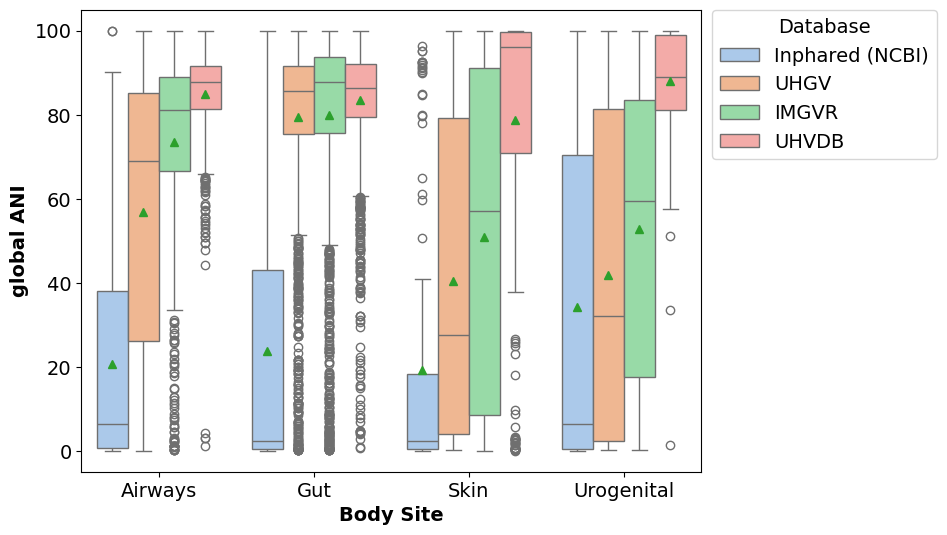

In [5]:
### Calculate global ANI of each assembled virus to the best hit in each database ###
uhgv_best_hit = (
    uhgv_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('UHGV').alias('Database')
        ])
)

uhvdb_best_hit = (
    uhvdb_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('UHVDB').alias('Database')
        ])
)

imgvr_best_hit = (
    imgvr_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('IMGVR').alias('Database')
        ])
)

inphared_best_hit = (
    inphared_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('Inphared').alias('Database')
        ])
)

best_hits = pl.concat([inphared_best_hit, uhgv_best_hit, imgvr_best_hit, uhvdb_best_hit])

best_hits = (
    best_hits
        .with_columns([
            pl.col('Database').str.replace('Inphared', 'Inphared (NCBI)'),
            pl.col('body_site').str.replace('airways', 'Airways').str.replace('gut', 'Gut').str.replace('skin', 'Skin').str.replace('urogenital', 'Urogenital')
        ])
)

import seaborn as sns
import matplotlib.pyplot as plt
sns.reset_orig()
plt.rcParams.update({'font.size': 14})


plt.figure(figsize=(8, 6))

sns.boxplot(x='body_site', y='qani', hue='Database', palette='pastel', data=best_hits, showmeans=True, order=['Airways', 'Gut', 'Skin', 'Urogenital'])
plt.xlabel('Body Site', fontdict={'fontweight': 'bold'})
plt.ylabel('global ANI', fontdict={'fontweight': 'bold'})
plt.legend(title='Database', bbox_to_anchor=(1.38, 1), loc='upper right', borderaxespad=0)
# plt.tight_layout()
plt.show()

In [8]:
best_hits

qname,tname,num_alns,pid,qcov,tcov,qani,acc,bioproject,biosample,consent,releasedate,librarysource,libraryselection,librarylayout,platform,instrument,organism,mbases,avgspotlen,assay_type,group,sample,body_site,Database
str,str,i64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str
"""DRR576658_k251_2015""","""MT980839""",6,89.89,4.57,5.15,4.107973,"""DRR576658""","""PRJDB18359""","""SAMD00797386""","""public""","""2025-06-16""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",9819,298,"""WGS""","""SAMD00797386""","""DRR576658""","""Gut""","""Inphared (NCBI)"""
"""DRR576658_k251_3293""","""PQ571303""",4,84.92,2.67,2.9,2.267364,"""DRR576658""","""PRJDB18359""","""SAMD00797386""","""public""","""2025-06-16""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",9819,298,"""WGS""","""SAMD00797386""","""DRR576658""","""Gut""","""Inphared (NCBI)"""
"""DRR576658_k251_62816""",null,null,null,null,null,null,"""DRR576658""","""PRJDB18359""","""SAMD00797386""","""public""","""2025-06-16""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",9819,298,"""WGS""","""SAMD00797386""","""DRR576658""","""Gut""","""Inphared (NCBI)"""
"""DRR576658_k251_59557|provirus_…",null,null,null,null,null,null,"""DRR576658""","""PRJDB18359""","""SAMD00797386""","""public""","""2025-06-16""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",9819,298,"""WGS""","""SAMD00797386""","""DRR576658""","""Gut""","""Inphared (NCBI)"""
"""DRR576658_k251_62769|provirus_…","""OP172779""",1,75.75,1.45,1.44,1.098375,"""DRR576658""","""PRJDB18359""","""SAMD00797386""","""public""","""2025-06-16""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",9819,298,"""WGS""","""SAMD00797386""","""DRR576658""","""Gut""","""Inphared (NCBI)"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SRR33963736_k251_98182|proviru…","""UHVDB-404259""",3,98.56,89.3,82.13,88.01408,"""SRR33963736""","""PRJNA1274164""","""SAMN49039747""","""public""","""2025-06-13""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq 6000""","""human gut metagenome""",7625,291,"""WGS""","""SAMN49039747""","""SRR33963736""","""Gut""","""UHVDB"""
"""SRR34389166_k251_18965|proviru…","""UHVDB-404536""",15,93.76,87.99,91.54,82.499424,"""SRR34389166""","""PRJNA1287223""","""SAMN49814640""","""public""","""2025-07-06""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina NovaSeq X Plus""","""human gut metagenome""",9828,277,"""WGS""","""SAMN49814640""","""SRR34389166""","""Gut""","""UHVDB"""
"""SRR34540143_k251_84692""","""UHVDB-250203""",11,96.22,74.52,78.77,71.703144,"""SRR34540143""","""PRJNA1045596""","""SAMN49972063""","""public""","""2025-07-15""","""METAGENOMIC""","""RANDOM""","""PAIRED""","""ILLUMINA""","""Illumina HiSeq 2500""","""human gut metagenome""",8651,215,"""WGS""","""SAMN49972063""","""SRR34540143""","""Gut""","""UHVDB"""


In [9]:
# print mean identity values for each body site and database
for body_site in ['Gut', 'Airways', 'Skin', 'Urogenital']:
    for database in ['UHGV', 'UHVDB', 'IMGVR', 'Inphared (NCBI)']:
        mean_id = best_hits.filter(
            (pl.col('body_site') == body_site) &
            (pl.col('Database') == database)
        ).select(pl.col('qani').mean()).item()
        print(f"Mean % identity for {body_site} samples to {database}: {mean_id}")

Mean % identity for Gut samples to UHGV: 79.51238356943799
Mean % identity for Gut samples to UHVDB: 83.55353896772706
Mean % identity for Gut samples to IMGVR: 80.01700563167672
Mean % identity for Gut samples to Inphared (NCBI): 23.68604453685027
Mean % identity for Airways samples to UHGV: 56.8544727875
Mean % identity for Airways samples to UHVDB: 84.96615452248679
Mean % identity for Airways samples to IMGVR: 73.61581635317998
Mean % identity for Airways samples to Inphared (NCBI): 20.765671663090128
Mean % identity for Skin samples to UHGV: 40.37816526548672
Mean % identity for Skin samples to UHVDB: 78.68267620599251
Mean % identity for Skin samples to IMGVR: 50.94744150622407
Mean % identity for Skin samples to Inphared (NCBI): 19.345785694214875
Mean % identity for Urogenital samples to UHGV: 41.9102456313364
Mean % identity for Urogenital samples to UHVDB: 88.0964871446281
Mean % identity for Urogenital samples to IMGVR: 52.77821163876653
Mean % identity for Urogenital sample